In [64]:
using JLD2,Plots,LinearAlgebra


In [65]:
s1=load("0.7radius15.0num_points20.0uD5.0er3.0NL0.0tgden0.01temp0.0JH12.0CNP1.5ildis0.0shift_l10.0shift_l21.0trytime.jld2")

Dict{String, Any} with 20 entries:
  "eig_vec_set"            => Vector{Matrix{ComplexF64}}[[[-0.0931442-0.215142i…
  "energy"                 => -3.88627
  "eout"                   => 8.72056e-15
  "parent_energy"          => -3.59069
  "Hartree_matrix"         => ComplexF64[-11.9678+0.0im 0.0+0.0im … 0.0+0.0im 0…
  "parent_HF_eigenvalues"  => [-132.195 -113.568 … -113.568 -132.195; -127.372 …
  "renormalized_density"   => 0.0
  "parent_Hartree_matrix"  => ComplexF64[-12.5424+0.0im 0.0+0.0im … 0.0+0.0im 0…
  "eig_set"                => [[[-643.507, -440.394, -119.653, 154.516, 444.019…
  "fermi_level"            => -13.4478
  "single_matrix"          => ComplexF64[-119.653+0.0im 0.0+0.0im … 0.0+0.0im 0…
  "final_density_matrix"   => ComplexF64[-2.62605e-5+0.0im 0.0+0.0im … 7.90346e…
  "parent_Fock_matrix"     => ComplexF64[-4.82305-3.39717e-17im 0.0+0.0im … 0.0…
  "k_index"                => [[1, 1], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], …
  "parent_HF_eigenvectors" => ComplexF64[-3

In [66]:
k_set=s1["k_set"]
k_index=s1["k_index"]
HF_eigenvalues=s1["HF_eigenvalues"]
parent_HF_eigenvalues=s1["parent_HF_eigenvalues"]
parent_Hartree_matrix=s1["parent_Hartree_matrix"]
single_matrix=s1["single_matrix"]
parent_Fock_matrix=s1["parent_Fock_matrix"]
parent_DS=s1["parent_DS"]
spin_num=2
layer_num=2
valley_num=2

parent_DS=reshape(parent_DS,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num,length(k_set))

4×2×4×2×225 Array{ComplexF64, 5}:
[:, :, 1, 1, 1] =
 -9.34787e-15+0.0im          0.0+0.0im
          0.0+0.0im          0.0+0.0im
  4.56281e-20-1.09982e-20im  0.0+0.0im
          0.0+0.0im          0.0+0.0im

[:, :, 2, 1, 1] =
         0.0+0.0im          0.0+0.0im
 4.39146e-16+0.0im          0.0+0.0im
         0.0+0.0im          0.0+0.0im
 -1.4033e-25+2.79689e-28im  0.0+0.0im

[:, :, 3, 1, 1] =
 4.56281e-20+1.09982e-20im  0.0+0.0im
         0.0+0.0im          0.0+0.0im
 6.61081e-16+0.0im          0.0+0.0im
         0.0+0.0im          0.0+0.0im

[:, :, 4, 1, 1] =
         0.0+0.0im          0.0+0.0im
 -1.4033e-25-2.79689e-28im  0.0+0.0im
         0.0+0.0im          0.0+0.0im
 3.54538e-18+0.0im          0.0+0.0im

[:, :, 1, 2, 1] =
 0.0+0.0im   9.78839e-15+0.0im
 0.0+0.0im           0.0+0.0im
 0.0+0.0im  -1.70891e-19-6.9374e-20im
 0.0+0.0im           0.0+0.0im

[:, :, 2, 2, 1] =
 0.0+0.0im           0.0+0.0im
 0.0+0.0im   1.75708e-27+0.0im
 0.0+0.0im           0.0+0.0im
 0.0+0.0im  -7.62

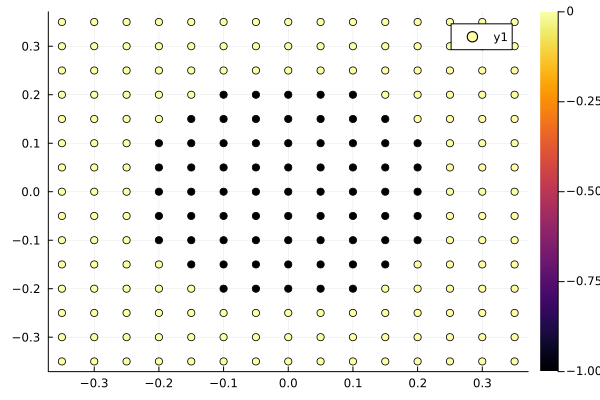

In [67]:
v1=[]
v2=[]
v3=[]

valley_z=zeros(ComplexF64,spin_num,valley_num,spin_num,valley_num)
for ja in 1:spin_num
  valley_z[ja,:,ja,:]=[1 0;0 -1]
end
valley_z=reshape(valley_z,spin_num*valley_num,spin_num*valley_num)


for ja in eachindex(k_set)
  push!(v1,k_set[ja][1])
  push!(v2,k_set[ja][2])
  push!(v3,tr(valley_z*parent_DS[:,1,:,1,ja]))
end
scatter(v1,v2,zcolor=real(v3))

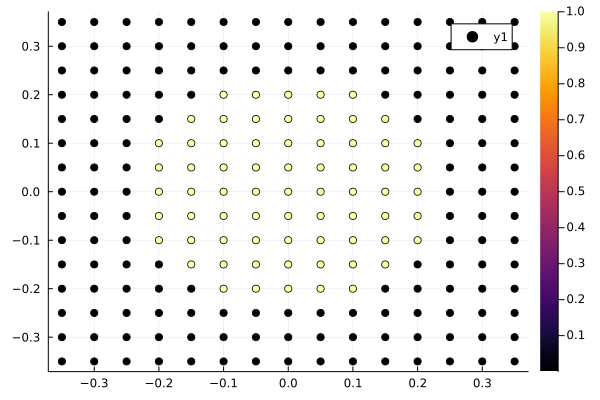

In [68]:
v1=[]
v2=[]
v3=[]

valley_z=zeros(ComplexF64,spin_num,valley_num,spin_num,valley_num)
for ja in 1:spin_num
  valley_z[ja,:,ja,:]=[1 0;0 -1]
end
valley_z=reshape(valley_z,spin_num*valley_num,spin_num*valley_num)


for ja in eachindex(k_set)
  push!(v1,k_set[ja][1])
  push!(v2,k_set[ja][2])
  push!(v3,tr(valley_z*parent_DS[:,2,:,2,ja]))
end
scatter(v1,v2,zcolor=real(v3))

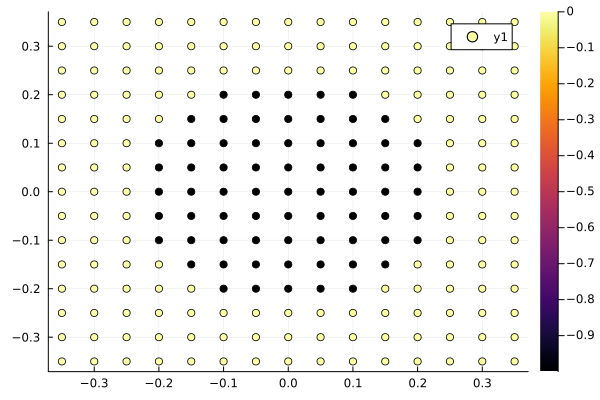

In [69]:
spin_z=zeros(ComplexF64,spin_num,valley_num,spin_num,valley_num)
for ja in 1:valley_num
  spin_z[:,ja,:,ja]=[1 0;0 -1]
end
spin_z=reshape(spin_z,spin_num*valley_num,spin_num*valley_num)

v1=[]
v2=[]
v3=[]
for ja in eachindex(k_set)
  push!(v1,k_set[ja][1])
  push!(v2,k_set[ja][2])
  push!(v3,tr(spin_z*parent_DS[:,1,:,1,ja]))
end
scatter(v1,v2,zcolor=real(v3))

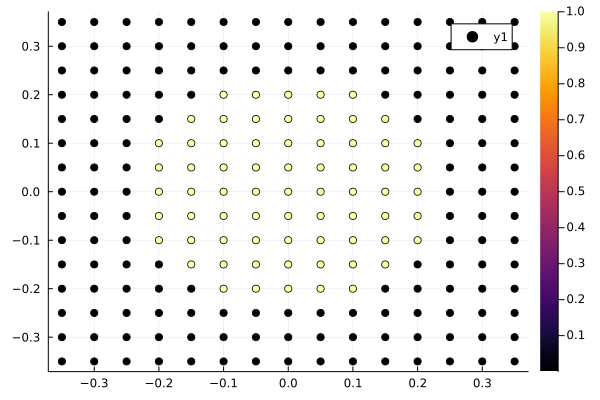

In [70]:

v1=[]
v2=[]
v3=[]
for ja in eachindex(k_set)
  push!(v1,k_set[ja][1])
  push!(v2,k_set[ja][2])
  push!(v3,tr(spin_z*parent_DS[:,2,:,2,ja]))
end
scatter(v1,v2,zcolor=real(v3))

In [71]:
parent_DS=reshape(parent_DS,spin_num,valley_num,layer_num,spin_num,valley_num,layer_num,length(k_set))
sum(abs.(parent_DS[:,1,:,:,2,:,:]))

0.0009375494546853833

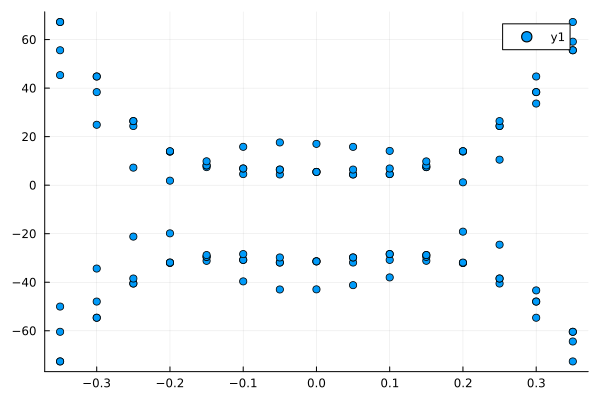

In [72]:
v1=[]
v2=[]
for ja in eachindex(k_set), jb in 1:8
    if k_index[ja][2]==6
      push!(v1,k_set[ja][1])
      push!(v2,HF_eigenvalues[jb,ja])
    end
  
end
scatter(v1,v2)

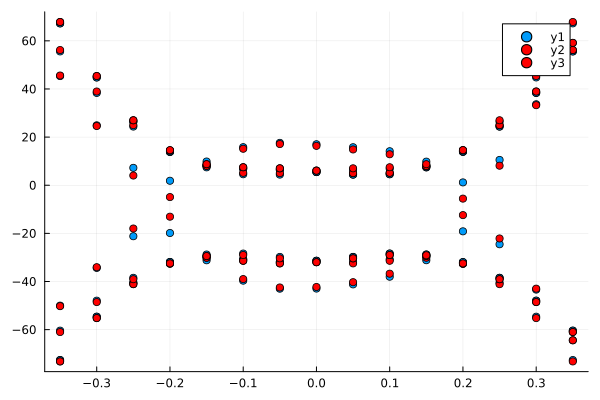

In [73]:

v1=[]
v2=[]
for ja in eachindex(k_set), jb in 1:8
    if k_index[ja][2]==6
      push!(v1,k_set[ja][1])
      push!(v2,HF_eigenvalues[jb,ja])
    end
  
end
scatter(v1,v2)

v1=[]
v2=[]
for ja in eachindex(k_set)
    if k_index[ja][2]==6
   
      ss=-parent_Fock_matrix[:,:,ja]+parent_Hartree_matrix[:,:,ja]+single_matrix[:,:,ja]
      ss=reshape(ss,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num)
      FFF=eigen(ss[:,1,:,1])
      for jb in 1:4
           push!(v1,k_set[ja][1])
           push!(v2,real(FFF.values[jb]))
      end
    end
  
end
scatter!(v1,v2,color=:red)

v1=[]
v2=[]
for ja in eachindex(k_set)
    if k_index[ja][2]==6
   
      ss=-parent_Fock_matrix[:,:,ja]+parent_Hartree_matrix[:,:,ja]+single_matrix[:,:,ja]
      ss=reshape(ss,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num)
      FFF=eigen(ss[:,2,:,2])
      for jb in 1:4
           push!(v1,k_set[ja][1])
           push!(v2,real(FFF.values[jb]))
      end
    end
  
end
scatter!(v1,v2,color=:red)

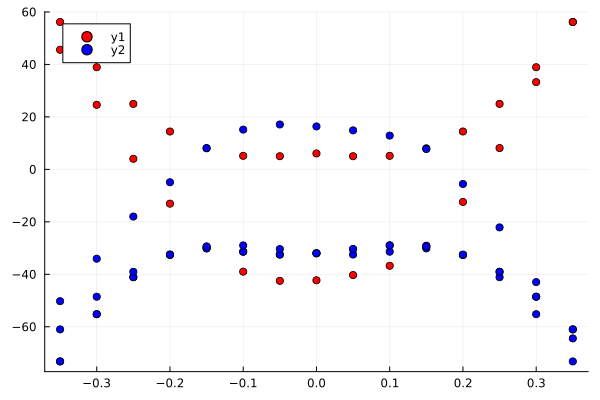

In [74]:
v1=[]
v2=[]
for ja in eachindex(k_set)
    if k_index[ja][2]==6
   
      ss=-parent_Fock_matrix[:,:,ja]+parent_Hartree_matrix[:,:,ja]+single_matrix[:,:,ja]
      ss=reshape(ss,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num)
      FFF=eigen(ss[:,2,:,2])
      for jb in 1:2
           push!(v1,k_set[ja][1])
           push!(v2,real(FFF.values[jb]))
      end
    end
  
end
scatter(v1,v2,color=:red)


v1=[]
v2=[]
for ja in eachindex(k_set)
    if k_index[ja][2]==6
   
      ss=-parent_Fock_matrix[:,:,ja]+parent_Hartree_matrix[:,:,ja]+single_matrix[:,:,ja]
      ss=reshape(ss,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num)
      FFF=eigen(ss[:,1,:,1])
      for jb in 1:4
           push!(v1,k_set[ja][1])
           push!(v2,real(FFF.values[jb]))
      end
    end
  
end
scatter!(v1,v2,color=:blue)